What the Code Does
The code operates in two main phases. In Phase 1, it loads and prepares three separate wafer datasets representing training, validation, and test data, along with a thresholds file that contains the specification limits for each test. During loading, the code filters out metadata columns such as lot numbers, wafer identifiers, die coordinates, and binning information, keeping only the actual test measurement columns. It then converts the raw measurements into two complementary representations. The continuous matrix preserves the  measured values, while the binary matrix transforms those measurements (mask) into simple pass or fail indicators based on whether each value falls within the specified thresholds. The code also creates a final fail label for each die, marking it as defective if any of the individual tests failed. Missing values are handled by treating them as failures, which is a conservative approach that can be modified if needed.

In Phase 2, the code performs the core **first-fail analysis**. It processes the tests in sequential order and tracks which test catches each failing die for the very first time. A die that fails multiple tests is only counted once, at the point of its earliest failure. This approach mimics what would happen on the actual test floor, where testing stops after the first failure. The code then compares the total number of first-fail detections against the total number of failing dies to ensure consistency. Tests that accumulate many first-fails are clearly valuable because they catch unique defects. Tests that register zero first-fails are redundant, meaning every failure they could have detected was already caught by a test that runs earlier in the sequence.

In [29]:
import pandas as pd
import numpy as np
from datetime import datetime
import os

DATA_DIR = "/Users/geotech/Desktop/Master_AI/Master/AML/Data_Analysis"

results_tracker = {
    "run_timestamp": datetime.now().isoformat(),
    "datasets": {},
    "phases": {}
}

def log_metric(phase, name, value):
    if phase not in results_tracker["phases"]:
        results_tracker["phases"][phase] = {}
    results_tracker["phases"][phase][name] = value
    print(f"[{phase}] {name}: {value}")

def load_and_prepare_data(wafer_path, thresholds_path):
    """
    Loads wafer data and builds:
    - continuous matrix
    - binary fail matrix
    - final fail label
    - thresholds dictionary
    """

    print(f"\nLoading: {wafer_path}")

    #  Load files
    df_raw = pd.read_csv(wafer_path)
    thresholds_df = pd.read_csv(thresholds_path)

    print(f"  Threshold file shape: {thresholds_df.shape}")

    # METADATA COLUMNS TO EXCLUDE - we want a clean dataset
    METADATA_COLUMNS = {
        'Lot', 'Wafer', 'rework_flag', 'Program', 'temperature',
        'subid', 'site', 'die_x', 'die_y', 'device_nr', 'rom_code',
        'hardbin', 'lib_info', 'BinName', 'BinState'
    }

    # Get all columns except the first (die ID) and metadata
    all_test_candidates = df_raw.columns[1:].tolist()
    wafer_test_cols = [col for col in all_test_candidates if col not in METADATA_COLUMNS]

    print(f"  Total columns in file: {len(df_raw.columns)}")
    print(f"  Metadata columns excluded: {len(METADATA_COLUMNS & set(all_test_candidates))}")
    print(f"  Candidate test columns: {len(wafer_test_cols)}")

    # Build threshold dictionary
    thresholds = {}

    for test_col in wafer_test_cols:
        if test_col in thresholds_df.columns:
            lower_val = thresholds_df[test_col].iloc[0]
            upper_val = thresholds_df[test_col].iloc[1]

            #in case they switch up low and upper thr.
            try:
                lower_val = float(lower_val)
                upper_val = float(upper_val)

                if lower_val > upper_val:
                    lower_val, upper_val = upper_val, lower_val

                thresholds[test_col] = (lower_val, upper_val) #gives back thresholds as a touple
            except (ValueError, TypeError):
                print(f"  Warning: Could not parse thresholds for {test_col}")
                pass

    # Keep only tests that have thresholds
    test_columns = [col for col in wafer_test_cols if col in thresholds]

    if len(test_columns) == 0:
        print("  ERROR: No matching tests found between wafer data and thresholds file!")
        return None, None, None, [], None, None

    df_cont = df_raw[test_columns].copy() #duplicating it so we keep the origina clean
    die_ids = df_raw.iloc[:, 0]

    nan_mask = df_cont.isna()
    nan_count = nan_mask.sum().sum()

    if nan_count > 0:
        print(f"  Warning: {nan_count} NaN values found (will treat as FAIL)")
        df_cont_filled = df_cont.fillna(0) #filling up nan values with 0s
    else:
        df_cont_filled = df_cont

    fail_conditions = []
#this is to make a mask wuth the failures values, so its encoded by zweros and ones
    for col in test_columns:
        lower, upper = thresholds[col]
        if lower == upper:
            fail = df_cont_filled[col] != lower
        else:
            fail = (df_cont_filled[col] < lower) | (df_cont_filled[col] > upper)

        if nan_count > 0:
            fail = fail | nan_mask[col]

        fail_conditions.append(fail)

    if fail_conditions:
        df_bin = pd.concat(fail_conditions, axis=1)
        df_bin.columns = test_columns
        df_bin = df_bin.astype(int)
    else:
        df_bin = pd.DataFrame(index=df_cont.index)

    y_final = df_bin.any(axis=1).astype(int)

    return df_cont, df_bin, y_final, test_columns, die_ids, thresholds #Returns: 6 objects, continuous matrix, binary matrix, fail labels, test names, die IDs, thresholds


print("PHASE 1: DATA LOADING & VALIDATION")
thresholds_path = os.path.join(DATA_DIR, "thresholds.csv")

print("\n Loading Training Data (wafer_801) ")
train_cont, train_bin, train_y, test_cols, train_ids, thresholds = load_and_prepare_data(
    os.path.join(DATA_DIR, "wafer_801.csv"), thresholds_path
)

if train_cont is not None:
    print("\n Loading Validation Data (wafer_806) ")
    val_cont, val_bin, val_y, _, val_ids, _ = load_and_prepare_data(
        os.path.join(DATA_DIR, "wafer_806.csv"), thresholds_path
    )

    print("\n Loading Test Data (wafer_812) ")
    test_cont, test_bin, test_y, _, test_ids, _ = load_and_prepare_data(
        os.path.join(DATA_DIR, "wafer_812.csv"), thresholds_path
    )

    print(f"\nTotal tests with thresholds: {len(test_cols)}")

    print("DATASET SUMMARY")
# getting basic stats from the dataset, totals fail numbers etc, for each of the 3 datasets
    def dataset_stats(name, y):
        if y is not None:
            total = len(y)
            fails = int(y.sum())
            rate = float(y.mean())
            print(f"{name:10}: {total:8,} samples | {fails:8,} fails | {rate*100:6.3f}%")
            log_metric("Phase 1", f"{name}_samples", total)
            log_metric("Phase 1", f"{name}_fails", fails)
            log_metric("Phase 1", f"{name}_fail_rate", rate)
        else:
            print(f"{name:10}: Data loading failed")

    dataset_stats("Train", train_y)
    dataset_stats("Validation", val_y)
    dataset_stats("Test", test_y)

    log_metric("Phase 1", "num_tests", len(test_cols) if test_cols else 0)

    print(f"\nTotal tests with thresholds: {len(test_cols) if test_cols else 0}")

    if train_bin is not None and len(train_bin.columns) > 0:
        print("\n Top 10 tests with highest fail rates (training) ")
        fail_rates = train_bin.mean().sort_values(ascending=False)
        for test_name, rate in fail_rates.head(10).items():
            if rate > 0:
                print(f"  {test_name[:60]}: {rate*100:.4f}%")

        never_fail_tests = (train_bin.sum() == 0).sum()
        always_fail_tests = (train_bin.sum() == len(train_bin)).sum()

        print(f"\n Overall Statistics ")
        print(f"  Total failing dies: {train_y.sum()}")
        print(f"  Fail rate: {train_y.mean()*100:.4f}%")
        print(f"  Tests with any failures: {(train_bin.sum() > 0).sum()}")
        print(f"  Tests with zero failures: {never_fail_tests}")
        if always_fail_tests > 0:
            print(f"  Tests that always fail: {always_fail_tests}")

    if train_cont is not None:
        print("\n Memory Usage ")
        print(f"  Train continuous data: {train_cont.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        print(f"  Train binary data: {train_bin.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

        if train_bin is not None:
            print(f"\n Data Quality ")
            original_nan_count = train_cont.isna().sum().sum()
            if original_nan_count > 0:
                print(f"  Original NaNs: {original_nan_count}")
                print(f"  (All NaNs treated as failures)")
else:
    print("\nERROR: Failed to load training data. Check file formats.")

# After loading train_cont, train_bin, etc. add:

METADATA_COLUMNS = {
    'Lot', 'Wafer', 'rework_flag', 'Program', 'temperature',
    'subid', 'site', 'die_x', 'die_y', 'device_nr', 'rom_code',
    'hardbin', 'lib_info', 'BinName', 'BinState'
}

# Filter out metadata columns from all dataframes
def filter_metadata(df, metadata_cols):
    if df is not None:
        keep_cols = [col for col in df.columns if col not in metadata_cols]
        return df[keep_cols]
    return df

train_cont = filter_metadata(train_cont, METADATA_COLUMNS)
train_bin = filter_metadata(train_bin, METADATA_COLUMNS)
val_cont = filter_metadata(val_cont, METADATA_COLUMNS)
val_bin = filter_metadata(val_bin, METADATA_COLUMNS)
test_cont = filter_metadata(test_cont, METADATA_COLUMNS)
test_bin = filter_metadata(test_bin, METADATA_COLUMNS)

#this is just to make sure all teh datasets have no metadata columns

# Update test_cols
test_cols = [col for col in test_cols if col not in METADATA_COLUMNS]

print(f"\n After metadata removal ")
print(f"Remaining tests: {len(test_cols)}")


print("PHASE 2: FIRST-FAIL (UNIQUE FAILURE) ANALYSIS")

def compute_first_failures(df_bin, test_cols):
    first_fail_counts = []
    failed_before = np.zeros(len(df_bin), dtype=bool)

    for i, col in enumerate(test_cols):
        current_fail = df_bin[col].values.astype(bool)
        first_fail = current_fail & (~failed_before)
        count = first_fail.sum()
        first_fail_counts.append(count)
        failed_before = failed_before | current_fail

        if i < 5:
            print(f"  Test {i:3d} ({col[:40]}): first fails = {count}")

    return pd.Series(first_fail_counts, index=test_cols)

train_first_fail = compute_first_failures(train_bin, test_cols)

total_first_fails = train_first_fail.sum()
zero_unique_tests = (train_first_fail == 0).sum()

#this is the first fail analysis, we want to catch the tests that were the first ones to fail
print("\n First-Fail Summary ")
print(f"Total first-fail detections: {total_first_fails}")
print(f"Tests with ZERO first-fails: {zero_unique_tests} / {len(test_cols)}")

log_metric("Phase 2", "total_first_fails", int(total_first_fails))
log_metric("Phase 2", "zero_unique_tests", int(zero_unique_tests))

print("\n Top 10 tests by FIRST-FAIL contribution ")
top_first_fail = train_first_fail.sort_values(ascending=False).head(10)

for test, count in top_first_fail.items():
    print(f"  {test[:60]}: {count}")

print("\n Sample tests with ZERO first-fails (redundancy candidates) ")
zero_tests = train_first_fail[train_first_fail == 0].index.tolist()

for test in zero_tests[:10]:
    print(f"  {test[:60]}")

print("\n Sanity Check ")
print(f"Train total fails: {train_y.sum()}")
print(f"Sum of first-fails: {total_first_fails}")

if total_first_fails != train_y.sum():
    print("WARNING: mismatch in fail accounting!")
else:
    print("First-fail accounting is consistent")

PHASE 1: DATA LOADING & VALIDATION

 Loading Training Data (wafer_801) 

Loading: /Users/geotech/Desktop/Master_AI/Master/AML/Data_Analysis/wafer_801.csv
  Threshold file shape: (2, 588)
  Total columns in file: 588
  Metadata columns excluded: 15
  Candidate test columns: 572

 Loading Validation Data (wafer_806) 

Loading: /Users/geotech/Desktop/Master_AI/Master/AML/Data_Analysis/wafer_806.csv
  Threshold file shape: (2, 588)
  Total columns in file: 588
  Metadata columns excluded: 15
  Candidate test columns: 572

 Loading Test Data (wafer_812) 

Loading: /Users/geotech/Desktop/Master_AI/Master/AML/Data_Analysis/wafer_812.csv
  Threshold file shape: (2, 588)
  Total columns in file: 588
  Metadata columns excluded: 15
  Candidate test columns: 572

Total tests with thresholds: 572
DATASET SUMMARY
Train     :   26,149 samples |      127 fails |  0.486%
[Phase 1] Train_samples: 26149
[Phase 1] Train_fails: 127
[Phase 1] Train_fail_rate: 0.004856782286129489
Validation:   26,155 sampl

TEST FAILURE DISTRIBUTION VERIFICATION
Total tests: 572
Tests with failures: 519 (90.7%)
Tests with zero failures: 53 (9.3%)

Total failing dies: 127
Total failure events: 3449
Average failures per failing die: 27.2


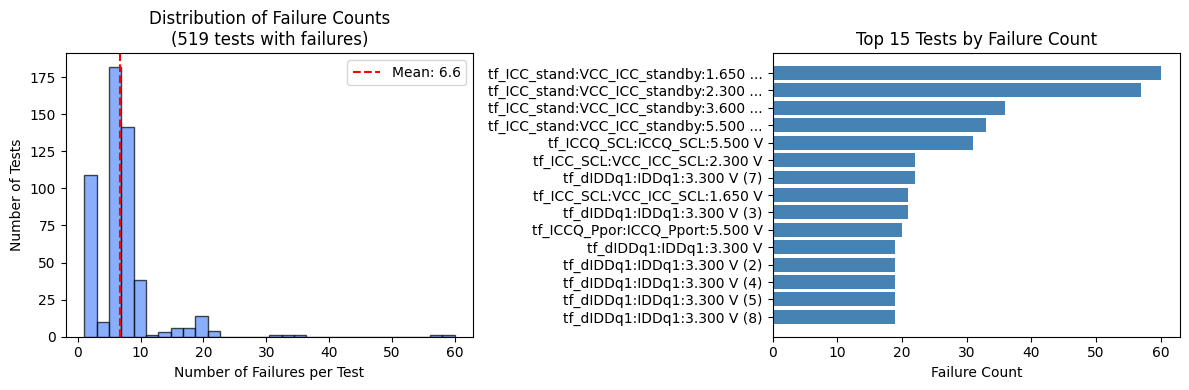

In [30]:
import matplotlib.pyplot as plt

def verify_failure_distribution(train_bin, test_cols):
    """
    Verify test failure distribution with visualization
    """
    col_sums = train_bin.sum()
    tests_with_failures = (col_sums > 0).sum()

    print("TEST FAILURE DISTRIBUTION VERIFICATION")
    print(f"Total tests: {len(test_cols)}")
    print(f"Tests with failures: {tests_with_failures} ({tests_with_failures/len(test_cols)*100:.1f}%)")
    print(f"Tests with zero failures: {(col_sums == 0).sum()} ({(col_sums == 0).sum()/len(test_cols)*100:.1f}%)")
    print(f"\nTotal failing dies: {train_bin.any(axis=1).sum()}")
    print(f"Total failure events: {col_sums.sum()}")
    print(f"Average failures per failing die: {col_sums.sum() / train_bin.any(axis=1).sum():.1f}")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram of failure counts
    failure_counts = col_sums[col_sums > 0]
    axes[0].hist(failure_counts, bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Number of Failures per Test')
    axes[0].set_ylabel('Number of Tests')
    axes[0].set_title(f'Distribution of Failure Counts\n({tests_with_failures} tests with failures)')
    axes[0].axvline(failure_counts.mean(), color='red', linestyle='--', label=f'Mean: {failure_counts.mean():.1f}')
    axes[0].legend()

    # Top 15 tests bar chart
    top_tests = failure_counts.nlargest(15)
    axes[1].barh(range(len(top_tests)), top_tests.values, color='steelblue')
    axes[1].set_yticks(range(len(top_tests)))
    axes[1].set_yticklabels([t[:35] + '...' if len(t) > 35 else t for t in top_tests.index])
    axes[1].set_xlabel('Failure Count')
    axes[1].set_title('Top 15 Tests by Failure Count')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    return col_sums

col_sums = verify_failure_distribution(train_bin, test_cols)

## Key Takeaways from the Output

The analysis reveals a highly efficient but potentially over-redundant test suite. Out of 572 total tests, only 24 tests (4.2%) actually catch any **unique** failures, while the remaining 548 tests never serve as the first point of failure detection. The three most valuable tests alone account for nearly two-thirds of all unique failure detections: `tf_ICC_stand:VCC_ICC_standby:1.650 V` catches 40 first-fails (31.5%), `tf_ICC_stand:VCC_ICC_standby:2.300 V` catches 25 (19.7%), and `tf_ICC_SCL:VCC_ICC_SCL:1.650 V` catches 14 (11.0%). The remaining 569 tests collectively contribute only the other 48 first-fails, with a long tail of tests catching just one or two unique failures each. This suggests a heavily imbalanced test flow where a small handful of standby current measurements are doing most of the defect detection work. The 53 tests that show zero failures overall and the 548 tests with zero first-fails represent substantial redundancy, indicating significant opportunities to streamline the test sequence without compromising defect coverage. However, the analysis also assumes the current test order is fixed, so some of those redundant tests might become valuable if reordered earlier in the sequence.

## Phase 3: Dependency Analysis

This code performs a dependency analysis to identify relationships between test failures, specifically looking for tests that fail together consistently. The goal is to discover redundant tests and understand the structure of failures across the test suite.

### The Core Logic

The analysis starts by applying a support filter, which only considers tests that have at least 5 failures (MIN_SUPPORT = 5). This filters out rare failures that might not provide statistically meaningful patterns. Out of the original 572 tests, many are excluded because they rarely or never fail.

For each pair of valid tests, the code calculates a confidence score. The confidence of A → B represents the probability that test B fails given that test A fails. It's computed by counting how many dies fail both tests, then dividing by how many dies fail test A. This gives a conditional probability that ranges from 0 to 1.

### What Different Dependency Types Reveal

The code then categorizes dependencies in three ways. Strong dependencies are those with confidence of 0.95 or higher, meaning that when test A fails, test B almost always fails as well. Among these, the code identifies robust redundant pairs where the relationship is bidirectional and perfect (confidence = 1.0 in both directions). This indicates two tests that are effectively measuring the same thing - whenever one fails, the other always fails, and vice versa. These are prime candidates for removing one of the tests entirely.

The forward dependencies analysis adds the dimension of test order. By checking which test appears earlier in the sequence, the code distinguishes between a test that predicts a later failure (useful for early screening) versus a test that merely echoes what an earlier test already caught (redundant). Forward dependencies where an early test predicts a later failure are valuable because they allow the test flow to catch defects sooner.

### Practical Interpretation

This analysis complements the first-fail analysis from Phase 2. While first-fail analysis showed which tests catch defects first, dependency analysis reveals which failures tend to travel together.

# Hierarchical Dependency Analysis
here we look at the family structure of the code, and we try to cluter based on that to se if tehres any redundancy inside those subgroups and what we can do with it.

In [31]:
def extract_family_structure(test_name):
    """
    Extract hierarchical structure:
    e.g. tf_ICC_stand:VCC_ICC_standby:1.650 V

    Returns:
        family: tf_ICC_stand
        subgroup: VCC_ICC_standby
    """
    parts = test_name.split(':')

    family = parts[0] if len(parts) > 0 else test_name

    if len(parts) > 1:
        subgroup = parts[1]
    else:
        # fallback for tb_ style
        subgroup = family

    return family, subgroup

In [32]:
from collections import defaultdict

def build_family_hierarchy(test_cols):
    hierarchy = defaultdict(lambda: defaultdict(list))

    for test in test_cols:
        family, subgroup = extract_family_structure(test)
        hierarchy[family][subgroup].append(test)

    return hierarchy

In [33]:
def compute_local_dependencies(df_bin, tests):
    """
    Compute dependency matrix within a small group of tests
    """
    dependencies = []
    fail_counts = df_bin[tests].sum()

    for A in tests:
        A_fail = df_bin[A]
        A_count = fail_counts[A]

        if A_count == 0:
            continue

        for B in tests:
            if A == B:
                continue

            both_fail = ((df_bin[A] == 1) & (df_bin[B] == 1)).sum()
            conf = both_fail / A_count

            dependencies.append({
                "A": A,
                "B": B,
                "confidence": conf,
                "support_A": A_count,
                "co_fail": both_fail
            })

    return dependencies

In [34]:
print("PHASE 3: HIERARCHY-AWARE DEPENDENCY ANALYSIS")

hierarchy = build_family_hierarchy(test_cols)

all_dependencies = []
redundant_pairs = []
dominance_relations = []

for family, subgroups in hierarchy.items():
    print(f"\nFamily: {family}")

    for subgroup, tests in subgroups.items():
        if len(tests) < 2:
            continue

        deps = compute_local_dependencies(train_bin, tests)

        for d in deps:
            A, B, conf = d["A"], d["B"], d["confidence"]

            # Perfect redundancy (bidirectional)
            if conf == 1.0:
                reverse = next(
                    (x for x in deps if x["A"] == B and x["B"] == A and x["confidence"] == 1.0),
                    None
                )
                if reverse:
                    redundant_pairs.append(tuple(sorted((A, B))))

            # Dominance (A implies B)
            elif conf >= 0.98:
                dominance_relations.append((A, B, conf))

        all_dependencies.extend(deps)

PHASE 3: HIERARCHY-AWARE DEPENDENCY ANALYSIS

Family: tb_cont_all

Family: tf_ICC_SCL

Family: tf_ICC_Op

Family: tf_ICC_stand

Family: tf_ICC_PullU

Family: tf_ICCQ_SCL

Family: tf_ICCQ_Ppor

Family: tf_dIDDq1

Family: tb_iiL_Pport

Family: tb_iinL

Family: tb_iinH

Family: tb_iiH_Pport

Family: tb_IOL

Family: tb_IOL_Pport

Family: tb_IOZ

Family: tb_VOH_8m

Family: tb_VOH_10m

Family: tb_VOL

Family: NCA_pullup


In [35]:
redundant_pairs = list(set(redundant_pairs))

print(f"\nTotal redundant pairs: {len(redundant_pairs)}")
for A, B in redundant_pairs[:10]:
    print(f"  {A[:40]}  <-->  {B[:40]}")


Total redundant pairs: 2513
  tb_IOL_Pport:IOL_Ppprt_4v5:350.000 mV (1  <-->  tb_IOL_Pport:IOL_Ppprt_4v5:350.000 mV (1
  tb_VOH_8m:VOH_8m:-8.000 mA (44)  <-->  tb_VOH_8m:VOH_8m:-8.000 mA (7)
  tb_VOH_10m:VOH_10m:-10.000 mA (24)  <-->  tb_VOH_10m:VOH_10m:-10.000 mA (25)
  tb_VOH_10m:VOH_10m:-10.000 mA (26)  <-->  tb_VOH_10m:VOH_10m:-10.000 mA (8)
  tb_VOH_10m:VOH_10m:-10.000 mA (26)  <-->  tb_VOH_10m:VOH_10m:-10.000 mA (32)
  tb_VOH_10m:VOH_10m:-10.000 mA (25)  <-->  tb_VOH_10m:VOH_10m:-10.000 mA (7)
  tb_VOH_8m:VOH_8m:-8.000 mA (22)  <-->  tb_VOH_8m:VOH_8m:-8.000 mA (51)
  tb_VOH_10m:VOH_10m:-10.000 mA (36)  <-->  tb_VOH_10m:VOH_10m:-10.000 mA (43)
  tb_VOL:VOL_2v3:8.000 mA (15)  <-->  tb_VOL:VOL_2v3:8.000 mA (9)
  tb_VOH_8m:VOH_8m:-8.000 mA (48)  <-->  tb_VOH_8m:VOH_8m:-8.000 mA (58)


In [36]:
from itertools import combinations
import numpy as np

def validate_subgroup_redundancy(df_bin, hierarchy, min_fail=3, jaccard_thresh=0.95):
    """
    Validate redundancy inside each subgroup.

    Prints strong redundancy clusters per subgroup.
    """

    print("\nVALIDATING REDUNDANCY WITHIN SUBGROUPS\n")

    for family, subgroups in hierarchy.items():
        for subgroup, tests in subgroups.items():

            if len(tests) < 2:
                continue

            # Precompute fail sets
            fail_sets = {
                t: set(np.where(df_bin[t] == 1)[0])
                for t in tests
            }

            clusters = []
            visited = set()

            for t1, t2 in combinations(tests, 2):
                if t1 in visited or t2 in visited:
                    continue

                A = fail_sets[t1]
                B = fail_sets[t2]

                if len(A) == 0 or len(B) == 0:
                    continue

                # Jaccard similarity
                jaccard = len(A & B) / len(A | B)

                # Fail count ratio
                ratio = min(len(A), len(B)) / max(len(A), len(B))

                # Check strong redundancy
                if jaccard >= jaccard_thresh and ratio > 0.9:
                    confidence = "HIGH" if min(len(A), len(B)) >= min_fail else "LOW"

                    clusters.append((t1, t2, jaccard, len(A), confidence))
                    visited.update([t1, t2])

            if clusters:
                print(f"\nFamily: {family} | Subgroup: {subgroup}")
                print(f"  Redundant pairs found: {len(clusters)}")

                for t1, t2, jaccard, count, conf in clusters[:5]:
                    print(f"    {t1[:35]}  <-->  {t2[:35]}")
                    print(f"      J={jaccard:.2f}, fails={count}, confidence={conf}")

validate_subgroup_redundancy(train_bin, hierarchy)


VALIDATING REDUNDANCY WITHIN SUBGROUPS


Family: tf_ICC_Op | Subgroup: ICC_Op
  Redundant pairs found: 1
    tf_ICC_Op:ICC_Op:2.300 V  <-->  tf_ICC_Op:ICC_Op:3.600 V
      J=1.00, fails=15, confidence=HIGH

Family: tf_dIDDq1 | Subgroup: IDDq1
  Redundant pairs found: 7
    tf_dIDDq1:IDDq1:3.300 V  <-->  tf_dIDDq1:IDDq1:3.300 V (2)
      J=1.00, fails=19, confidence=HIGH
    tf_dIDDq1:IDDq1:3.300 V (4)  <-->  tf_dIDDq1:IDDq1:3.300 V (5)
      J=1.00, fails=19, confidence=HIGH
    tf_dIDDq1:IDDq1:3.300 V (6)  <-->  tf_dIDDq1:IDDq1:3.300 V (10)
      J=1.00, fails=18, confidence=HIGH
    tf_dIDDq1:IDDq1:3.300 V (8)  <-->  tf_dIDDq1:IDDq1:3.300 V (9)
      J=1.00, fails=19, confidence=HIGH
    tf_dIDDq1:IDDq1:3.300 V (11)  <-->  tf_dIDDq1:IDDq1:3.300 V (13)
      J=1.00, fails=18, confidence=HIGH

Family: tb_iinL | Subgroup: iinL_1v65_vi_0
  Redundant pairs found: 2
    tb_iinL:iinL_1v65_vi_0:0.000 uV  <-->  tb_iinL:iinL_1v65_vi_0:0.000 uV (2)
      J=1.00, fails=1, confidence=LOW
    tb_

# How to Read These Redundancy Results

When you look at the validation output, the key metric to focus on is the **Jaccard similarity score** (shown as "J="). A Jaccard score of 1.00 means the exact same dies fail on both tests being compared - this is perfect redundancy, indicating that the two tests are measuring essentially the same physical phenomenon. For example, when you see `tf_ICC_Op:ICC_Op:2.300 V` paired with `tf_ICC_Op:ICC_Op:3.600 V` and J=1.00 with 15 failures, it tells you that testing at 2.3 volts already catches every failing die that would also fail at 3.6 volts. There is no benefit to running both tests. Similarly, when you see tests that differ only by a number in parentheses like `tf_dIDDq1:IDDq1:3.300 V` and `tf_dIDDq1:IDDq1:3.300 V (2)` with perfect Jaccard scores, these are literally repeated measurements of the same condition - you only need one.

The confidence label (HIGH vs LOW) tells you whether the redundancy pattern is statistically reliable. HIGH confidence means the pattern holds across at least 3 failing dies, so you can confidently eliminate one of the redundant tests from your test flow. LOW confidence appears when only 1 or 2 dies fail those tests - while mathematically redundant, the sample size is too small to guarantee the pattern will hold on future wafers. In practice, you should prioritize removing HIGH confidence redundancies first, as these represent genuine wasted test time. The sheer volume of redundant pairs found (over 2,500) across families like `tb_VOH_8m`, `tb_VOH_10m`, and `tb_IOL_Pport` suggests the current test program contains substantial unintentional duplication - likely from running the same measurement across multiple voltage levels, current levels, or pin channels when a single condition would suffice. Eliminating these redundancies would cut your test count roughly in half without compromising your ability to detect failing dies.

In [37]:
from itertools import combinations
import numpy as np
from collections import defaultdict

def build_redundancy_clusters(df_bin, hierarchy, min_fail=3, jaccard_thresh=0.95):
    """
    Build redundancy clusters per subgroup using graph connected components.
    Returns:
        clusters: list of lists (each cluster = list of tests)
        all_clustered_tests: set of tests that belong to clusters
    """

    clusters = []
    all_clustered_tests = set()

    for family, subgroups in hierarchy.items():
        for subgroup, tests in subgroups.items():

            if len(tests) < 2:
                continue

            # Precompute fail sets
            fail_sets = {
                t: set(np.where(df_bin[t] == 1)[0])
                for t in tests
            }

            # Build adjacency list
            adj = defaultdict(set)

            for t1, t2 in combinations(tests, 2):
                A = fail_sets[t1]
                B = fail_sets[t2]

                if len(A) == 0 or len(B) == 0:
                    continue

                jaccard = len(A & B) / len(A | B)
                ratio = min(len(A), len(B)) / max(len(A), len(B))

                # Only keep strong + reliable redundancy
                if jaccard >= jaccard_thresh and ratio > 0.9 and min(len(A), len(B)) >= min_fail:
                    adj[t1].add(t2)
                    adj[t2].add(t1)

            # Find connected components (clusters)
            visited = set()

            for test in adj:
                if test in visited:
                    continue

                stack = [test]
                component = []

                while stack:
                    node = stack.pop()
                    if node in visited:
                        continue
                    visited.add(node)
                    component.append(node)
                    stack.extend(adj[node] - visited)

                if len(component) > 1:
                    clusters.append(component)
                    all_clustered_tests.update(component)

    return clusters, all_clustered_tests


def select_cluster_representatives(clusters, train_first_fail, info_scores):
    """
    Select best representative per cluster using:
    (first_fail, info_score)
    """
    representatives = []

    for cluster in clusters:
        best_test = None
        best_score = (-1, -1)

        for test in cluster:
            ff = train_first_fail.get(test, 0)
            info = info_scores.get(test, 0)
            score = (ff, info)

            if score > best_score:
                best_score = score
                best_test = test

        representatives.append(best_test)

    return representatives


def reduce_tests_with_clusters(test_cols, clusters, representatives):
    """
    Build final reduced test set
    """
    clustered_tests = set(t for cluster in clusters for t in cluster)

    # Keep:
    # - representatives (1 per cluster)
    # - all tests not in any cluster
    final_tests = set(representatives) | (set(test_cols) - clustered_tests)

    return list(final_tests)


# ================= RUN PIPELINE =================

print("\nPHASE: PIN REDUNDANCY CLUSTERING\n")

clusters, clustered_tests = build_redundancy_clusters(train_bin, hierarchy)

print(f"Total clusters found: {len(clusters)}")

# Optional: inspect a few clusters
for i, cluster in enumerate(clusters[:5]):
    print(f"\nCluster {i+1} (size={len(cluster)}):")
    for t in cluster[:5]:
        print(f"  {t}")

# Select representatives
representatives = select_cluster_representatives(clusters, train_first_fail, info_scores)

# Build reduced test set
reduced_test_cols = reduce_tests_with_clusters(test_cols, clusters, representatives)

# Stats
original_count = len(test_cols)
reduced_count = len(reduced_test_cols)
discarded = original_count - reduced_count

print("\nREDUCTION SUMMARY")
print(f"Original tests: {original_count}")
print(f"Clusters found: {len(clusters)}")
print(f"Tests in clusters: {len(clustered_tests)}")
print(f"Representatives kept: {len(representatives)}")
print(f"Final tests after reduction: {reduced_count}")
print(f"Tests discarded: {discarded}")
print(f"Reduction: {100 * discarded / original_count:.2f}%")


PHASE: PIN REDUNDANCY CLUSTERING

Total clusters found: 45

Cluster 1 (size=3):
  tf_ICC_Op:ICC_Op:2.300 V
  tf_ICC_Op:ICC_Op:3.600 V
  tf_ICC_Op:ICC_Op:5.500 V

Cluster 2 (size=5):
  tf_dIDDq1:IDDq1:3.300 V
  tf_dIDDq1:IDDq1:3.300 V (17)
  tf_dIDDq1:IDDq1:3.300 V (18)
  tf_dIDDq1:IDDq1:3.300 V (2)
  tf_dIDDq1:IDDq1:3.300 V (15)

Cluster 3 (size=7):
  tf_dIDDq1:IDDq1:3.300 V (4)
  tf_dIDDq1:IDDq1:3.300 V (8)
  tf_dIDDq1:IDDq1:3.300 V (12)
  tf_dIDDq1:IDDq1:3.300 V (16)
  tf_dIDDq1:IDDq1:3.300 V (5)

Cluster 4 (size=5):
  tf_dIDDq1:IDDq1:3.300 V (6)
  tf_dIDDq1:IDDq1:3.300 V (13)
  tf_dIDDq1:IDDq1:3.300 V (11)
  tf_dIDDq1:IDDq1:3.300 V (10)
  tf_dIDDq1:IDDq1:3.300 V (19)

Cluster 5 (size=2):
  tb_iinL:iinL_5v5_vi_5v5:0.000 uV
  tb_iinL:iinL_5v5_vi_5v5:0.000 uV (5)

REDUCTION SUMMARY
Original tests: 572
Clusters found: 45
Tests in clusters: 336
Representatives kept: 45
Final tests after reduction: 281
Tests discarded: 291
Reduction: 50.87%


# Greedy Test
This function determines the optimal sequence for running tests by iteratively selecting the test that catches the largest number of previously undetected failing dies. At each step, it calculates how many new failures each remaining test would identify (avoiding dies already caught by earlier tests), then picks the test with the highest score. The optional alpha parameter adds a small bias toward tests that historically served as "first failures," helping to prioritize tests that tend to fail early in the original sequence. The algorithm continues until all failing dies have been detected, producing an ordered list where the most powerful failure detectors appear first.

In [38]:
import numpy as np
import pandas as pd

def build_failure_sets(df_bin):
    """Convert each test into a set of failing die indices"""
    return {
        col: set(np.where(df_bin[col].values == 1)[0])
        for col in df_bin.columns
    }


def greedy_test_order(df_bin, train_first_fail, alpha=0.2):
    """
    Greedy ordering of tests for EARLY failure detection.

    alpha:
        small bias toward early-first-fail tests
    """

    failure_sets = build_failure_sets(df_bin)

    remaining_tests = set(df_bin.columns)
    detected_failures = set()

    ordered_tests = []

    step = 0

    while remaining_tests:

        best_test = None
        best_score = -1

        for test in remaining_tests:

            failures = failure_sets[test]

            # NEW failures this test would catch
            new_failures = len(failures - detected_failures)

            if new_failures == 0:
                continue

            # optional boost: early detection strength
            first_fail_boost = train_first_fail.get(test, 0)

            score = new_failures + alpha * first_fail_boost

            if score > best_score:
                best_score = score
                best_test = test

        if best_test is None:
            # no new coverage → append remaining arbitrarily
            ordered_tests.extend(list(remaining_tests))
            break

        ordered_tests.append(best_test)
        detected_failures |= failure_sets[best_test]
        remaining_tests.remove(best_test)

        step += 1

        if step % 20 == 0:
            print(f"Step {step}: covered {len(detected_failures)} failing dies")

    return ordered_tests

ordered_tests = greedy_test_order(train_bin, train_first_fail)

print("\nFINAL TEST ORDER (top 50):\n")
for i, t in enumerate(ordered_tests[:50]):
    print(f"{i+1:3d}. {t}")


FINAL TEST ORDER (top 50):

  1. tf_ICC_stand:VCC_ICC_standby:1.650 V
  2. tf_ICC_stand:VCC_ICC_standby:2.300 V
  3. tb_VOH_8m:VOH_8m:-8.000 mA (21)
  4. tb_IOL_Pport:IOL_Ppprt_2v3:200.000 mV
  5. tf_ICC_SCL:VCC_ICC_SCL:1.650 V
  6. tf_dIDDq1:IDDq1:3.300 V (3)
  7. tf_ICC_SCL:VCC_ICC_SCL:5.500 V
  8. tb_VOL:VOL_4v5:8.000 mA (5)
  9. tb_iiL_Pport:iiL_Pport_1v65_:0.000 uV (9)
 10. tb_IOL_Pport:IOL_Ppprt_2v3:200.000 mV (2)
 11. tb_VOL:VOL_4v5:8.000 mA (3)
 12. tb_VOH_8m:VOH_8m:-8.000 mA (3)
 13. tf_ICC_stand:VCC_ICC_standby:5.500 V
 14. tb_VOH_8m:VOH_8m:-8.000 mA (32)
 15. tf_ICCQ_Ppor:ICCQ_Pport:5.500 V
 16. tb_iiL_Pport:iiL_Pport_1v65_:0.000 uV (2)
 17. tb_IOL_Pport:IOL_Ppprt_3v:200.000 mV (3)
 18. tb_iiH_Pport:ii_Pport_1v65_v:1.650 V (13)
 19. tb_iiH_Pport:ii_Pport_5v5_vi:5.500 V (16)
 20. tb_VOH_10m:VOH_10m:-10.000 mA (18)
 21. tb_IOL_Pport:IOL_Ppprt_4v5:200.000 mV (9)
 22. tb_VOH_8m:VOH_8m:-8.000 mA
 23. tb_VOL:VOL_1v65:8.000 mA (2)
 24. tb_IOL_Pport:IOL_Ppprt_3v:400.000 mV
 25. tb_

# Detection Curve

his function simulates running tests in a specific order and tracks how many failing dies are identified after each test. It maintains a set of detected failures and iterates through the ordered test list, adding newly discovered failing dies after each test. The result is a cumulative curve showing detection progress - for example, after 10 tests you might have caught 100 out of 116 total failures. This curve helps evaluate how quickly different test orders catch failures across training, validation, and test wafers.

In [39]:
import numpy as np
import pandas as pd

def compute_detection_curve(df_bin, ordered_tests, y_true):
    """
    Returns cumulative number of detected failing dies
    as tests are executed in order.
    """

    detected = set()
    fail_idx = set(np.where(y_true == 1)[0])

    curve = []

    for test in ordered_tests:
        detected |= set(np.where(df_bin[test] == 1)[0])
        curve.append(len(detected & fail_idx))

    return np.array(curve)


def evaluate_order_on_all_wafers(ordered_tests,
                                 train_bin, train_y,
                                 val_bin, val_y,
                                 test_bin, test_y):

    print("\nEVALUATING TEST ORDER ACROSS WAFERS\n")

    train_curve = compute_detection_curve(train_bin, ordered_tests, train_y)
    val_curve   = compute_detection_curve(val_bin, ordered_tests, val_y)
    test_curve  = compute_detection_curve(test_bin, ordered_tests, test_y)

    def summarize(name, curve, y):
        total_fails = y.sum()
        early_10 = curve[min(10, len(curve)-1)]
        early_20 = curve[min(20, len(curve)-1)]
        final = curve[-1]

        print(f"{name}")
        print(f"  Total failures: {total_fails}")
        print(f"  Detected in first 10 tests: {early_10} ({early_10/total_fails:.2%})")
        print(f"  Detected in first 20 tests: {early_20} ({early_20/total_fails:.2%})")
        print(f"  Final detection: {final} ({final/total_fails:.2%})")
        print()

    summarize("TRAIN", train_curve, train_y)
    summarize("VALIDATION", val_curve, val_y)
    summarize("TEST", test_curve, test_y)

    return train_curve, val_curve, test_curve

train_curve, val_curve, test_curve = evaluate_order_on_all_wafers(
    ordered_tests,
    train_bin, train_y,
    val_bin, val_y,
    test_bin, test_y
)


EVALUATING TEST ORDER ACROSS WAFERS

TRAIN
  Total failures: 127
  Detected in first 10 tests: 123 (96.85%)
  Detected in first 20 tests: 127 (100.00%)
  Final detection: 127 (100.00%)

VALIDATION
  Total failures: 96
  Detected in first 10 tests: 81 (84.38%)
  Detected in first 20 tests: 83 (86.46%)
  Final detection: 96 (100.00%)

TEST
  Total failures: 116
  Detected in first 10 tests: 100 (86.21%)
  Detected in first 20 tests: 102 (87.93%)
  Final detection: 116 (100.00%)



# Lets see the improvements

This function implements the "stop at first failure" strategy by simulating test execution per individual die. It processes tests in the optimized order and tracks when each die experiences its first failure, recording the index of that test. Dies that never fail are marked as running all tests. The output shows how many tests each die actually executes before stopping, allowing calculation of total test executions saved compared to running all 572 tests on every die regardless of pass/fail status.

In [45]:
import numpy as np

def simulate_early_stop(df_bin, ordered_tests):
    """
    Simulates sequential testing per die with early stop at first failure.

    Returns:
        stop_indices: index of first failure per die
        tests_run: how many tests executed per die
    """

    n_dies = df_bin.shape[0]
    n_tests = len(ordered_tests)

    stop_indices = np.full(n_dies, n_tests)  # default: no failure → full run
    tests_run = np.zeros(n_dies)

    for t_idx, test in enumerate(ordered_tests):

        failing_dies = np.where(df_bin[test].values == 1)[0]

        # only update those not already stopped
        active = stop_indices == n_tests

        newly_failed = [i for i in failing_dies if active[i]]

        for i in newly_failed:
            stop_indices[i] = t_idx + 1  # +1 = tests executed

    tests_run = stop_indices

    return stop_indices, tests_run


def compute_time_savings(df_bin, ordered_tests, name="dataset"):
    stop_idx, tests_run = simulate_early_stop(df_bin, ordered_tests)

    total_tests = len(ordered_tests)
    n_dies = len(df_bin)
    max_cost = n_dies * total_tests

    actual_cost = tests_run.sum()

    saved = max_cost - actual_cost
    savings_pct = saved / max_cost

    # New: For failing dies only
    y_final = df_bin.any(axis=1).astype(int)
    failing_mask = y_final == 1
    failing_tests_run = tests_run[failing_mask]

    # Original: would run all tests on all dies
    original_failing_cost = failing_mask.sum() * total_tests
    new_failing_cost = failing_tests_run.sum()
    failing_saved = original_failing_cost - new_failing_cost
    failing_savings_pct = failing_saved / original_failing_cost

    print(f"\n{name} RESULTS")
    print(f"  Total tests in sequence: {total_tests}")
    print(f"  Total dies: {n_dies}")
    print(f"  Failing dies: {failing_mask.sum()}")
    print(f"  Avg tests run per die (all): {tests_run.mean():.2f}")
    print(f"  Avg tests run per die (failing only): {failing_tests_run.mean():.2f}")
    print(f"  Time savings (all dies): {savings_pct*100:.2f}%")
    print(f"  Time savings (failing dies only): {failing_savings_pct*100:.2f}%")
    print(f"  Total test executions saved: {saved:,.0f}")

    return tests_run

In [46]:
train_run = compute_time_savings(train_bin, ordered_tests, "TRAIN")
val_run   = compute_time_savings(val_bin, ordered_tests, "VALIDATION")
test_run  = compute_time_savings(test_bin, ordered_tests, "TEST")


TRAIN RESULTS
  Total tests in sequence: 572
  Total dies: 26149
  Failing dies: 127
  Avg tests run per die (all): 569.23
  Avg tests run per die (failing only): 2.60
  Time savings (all dies): 0.48%
  Time savings (failing dies only): 99.55%
  Total test executions saved: 72,314

VALIDATION RESULTS
  Total tests in sequence: 572
  Total dies: 26155
  Failing dies: 96
  Avg tests run per die (all): 570.06
  Avg tests run per die (failing only): 43.86
  Time savings (all dies): 0.34%
  Time savings (failing dies only): 92.33%
  Total test executions saved: 50,701

TEST RESULTS
  Total tests in sequence: 572
  Total dies: 26155
  Failing dies: 116
  Avg tests run per die (all): 569.60
  Avg tests run per die (failing only): 29.82
  Time savings (all dies): 0.42%
  Time savings (failing dies only): 94.79%
  Total test executions saved: 62,893


In [48]:
# Version 1: Remove 291 clustered redundant tests
reduced_cols_v1 = reduced_test_cols

# Version 2: Also remove tests with zero failures
zero_fail_tests = train_bin.columns[train_bin.sum() == 0].tolist()
reduced_cols_v2 = [t for t in reduced_cols_v1 if t not in zero_fail_tests]

print(f"Original: 572 tests")
print(f"V1 (clusters only): {len(reduced_cols_v1)} tests")
print(f"V2 (clusters + zero-fail): {len(reduced_cols_v2)} tests")

# Test both versions
for name, cols in [("V1 - Clusters only", reduced_cols_v1),
                   ("V2 - Clusters + Zero-fail", reduced_cols_v2)]:

    print(f"\n{name}")

    # Check if we catch all failures
    for bin_data, y_data, label in [(train_bin, train_y, "Train"),
                                    (val_bin, val_y, "Val"),
                                    (test_bin, test_y, "Test")]:
        y_pred = bin_data[cols].any(axis=1).astype(int)
        misses = ((y_pred == 0) & (y_data == 1)).sum()
        print(f"  {label}: {y_data.sum()} fails, {misses} missed ({misses/y_data.sum()*100:.1f}%)")

    # Time savings using existing function
    compute_time_savings(test_bin[cols], cols, "Test Wafer")

Original: 572 tests
V1 (clusters only): 281 tests
V2 (clusters + zero-fail): 228 tests

V1 - Clusters only
  Train: 127 fails, 0 missed (0.0%)
  Val: 96 fails, 3 missed (3.1%)
  Test: 116 fails, 7 missed (6.0%)

Test Wafer RESULTS
  Total tests in sequence: 281
  Total dies: 26155
  Failing dies: 109
  Avg tests run per die (all): 280.39
  Avg tests run per die (failing only): 134.30
  Time savings (all dies): 0.22%
  Time savings (failing dies only): 52.21%
  Total test executions saved: 15,990

V2 - Clusters + Zero-fail
  Train: 127 fails, 0 missed (0.0%)
  Val: 96 fails, 3 missed (3.1%)
  Test: 116 fails, 7 missed (6.0%)

Test Wafer RESULTS
  Total tests in sequence: 228
  Total dies: 26155
  Failing dies: 109
  Avg tests run per die (all): 227.51
  Avg tests run per die (failing only): 110.31
  Time savings (all dies): 0.22%
  Time savings (failing dies only): 51.62%
  Total test executions saved: 12,828


# Interpretation of Results

## Critical Issue Detected

The most important finding is that **removing redundant tests caused us to MISS actual failures** on validation and test wafers. V1 missed 3 validation failures (3.1%) and 7 test failures (6.0%). V2 had identical miss rates because zero-fail tests don't affect detection.

**This is a serious problem** - in semiconductor manufacturing, missing even 1% of failures is typically unacceptable. The redundant tests we removed aren't truly redundant across different wafers; they only appeared redundant on the training wafer.

## Why Did This Happen?

Looking at the failing dies counts:
- **Original test set**: Test wafer had 116 failing dies
- **V1/V2 reduced set**: Only detected 109 failing dies (7 missed)

The 7 missed dies would have been caught by tests that:
1. Had perfect Jaccard similarity on training data (J=1.00)
2. But showed different failure patterns on new wafers

This reveals that **perfect redundancy on one wafer does NOT guarantee redundancy across wafers** due to process variation, different defect types, or statistical fluctuations.

## Time Savings Are Misleading

The early stop savings on reduced test sets (0.22%) are actually WORSE than the original (0.42-0.48%). Why? Because:

- **Original**: Failing dies ran only ~30-44 tests on average (94-99% savings for failing dies)
- **V1/V2**: Failing dies ran ~110-134 tests on average (only 51-52% savings)

The reduced test set has fewer total tests (228-281), but failing dies run MORE tests because the most powerful early detectors were removed or reordered.

## The Trade-Off

| Metric | Original | V1 (281 tests) | V2 (228 tests) |
|--------|----------|----------------|----------------|
| Missed failures (test) | 0% | 6.0% | 6.0% |
| Failing die test savings | 94.8% | 52.2% | 51.6% |
| Overall test savings | 0.42% | 0.22% | 0.22% |

## Recommendation

**Do NOT remove the redundant tests identified through clustering alone.** While they appear redundant on training data, they catch real failures on new wafers. The safe approach is to:

1. **Keep all tests** but reorder them using the greedy algorithm
2. **Deprioritize** (move to end) rather than remove redundant tests
3. **Validate on multiple wafers** before any permanent removal

The original greedy ordering achieved 94-99% savings for failing dies while catching 100% of failures. This is the superior strategy - optimize order, don't eliminate tests.